# Chapter 03 Probability and Distributions: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-03-probability-and-distributions-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

Suppose an anomaly detector pages the on-call engineer for the checkout API at 3 a.m. Before
reaching for a laptop, there is a question worth asking first: given that the alert fired, how
likely is it that something is wrong?

*Probability* is the branch of mathematics that answers questions shaped like this one.
*Distributions* describe the range of values a random quantity, like a latency measurement or
a request count, tends to take.

This chapter works through five questions that come up whenever uncertainty needs a number
attached to it:

1. *Given some new evidence, how should a prior belief update?*
   Bayes' theorem is the formal answer, and it is easy to get wrong by instinct alone.
2. *Which named distribution matches the mechanism producing a number?*
   Eight distributions cover most of what shows up in production systems, each tied to a
   specific generating process rather than chosen by looks.
3. *Why does the normal distribution show up everywhere, even when the underlying process
   is not normal at all?*
   The Central Limit Theorem explains the pattern.
4. *How surprising is a coincidence?*
   The birthday problem shows that collisions happen far sooner than intuition expects, with
   consequences for anything that generates random identifiers.
5. *How do sampling without replacement and uniform random assignment behave?*
   The mechanics behind drawing a canary cohort or assigning a request to a shard.

In [1]:
import os
import numpy as np
import plotly.graph_objects as go
from scipy import stats

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(11)

## Bayes' theorem: what an alert tells you

P(true incident given an alert) as the base rate of true incidents falls, holding detector sensitivity and specificity fixed. At a 1% base rate the probability collapses to about 8.8%, even from a detector that looks accurate on paper.

In [4]:
def fig_bayes_base_rate() -> go.Figure:
    sensitivity = 0.95  # P(alert | incident)
    specificity = 0.90  # P(no alert | no incident)
    base_rates = [0.30, 0.10, 0.05, 0.02, 0.01, 0.005]
    frames = []
    for p_incident in base_rates:
        p_no_incident = 1 - p_incident
        p_alert_given_incident = sensitivity
        p_alert_given_no_incident = 1 - specificity
        p_alert = (p_alert_given_incident * p_incident) + (p_alert_given_no_incident * p_no_incident)
        p_incident_given_alert = (p_alert_given_incident * p_incident) / p_alert
        frames.append(
            go.Frame(
                name=f"{p_incident:.1%}",
                data=[go.Bar(
                    x=["An alert fired"], y=[p_incident_given_alert],
                    marker_color="#E45756", width=[0.5],
                    text=[f"{p_incident_given_alert:.1%} true incident"],
                    textposition="outside",
                )],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False,
                    align="left",
                    text=(f"base rate of a true incident = {p_incident:.1%}<br>"
                          f"detector sensitivity = {sensitivity:.0%}, "
                          f"specificity = {specificity:.0%}"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    # Default view lands on the 1% base rate, the specific worked example the
    # chapter text computes by hand (about 8.8% true-incident probability), rather
    # than frame 0's 30% starting point. The slider still runs 30% down to 0.5%
    # for readers who want to see the full collapse for themselves.
    default_index = base_rates.index(0.01)
    fig = go.Figure(
        data=frames[default_index].data,
        frames=frames,
        layout=frames[default_index].layout,
    )
    fig.update_layout(
        title="P(true incident | alert fired) collapses as incidents get rarer",
        yaxis_title="P(true incident | alert fired)",
        yaxis_range=[0, 1],
        sliders=[{
            "active": default_index,
            "currentvalue": {"prefix": "base rate of a true incident: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

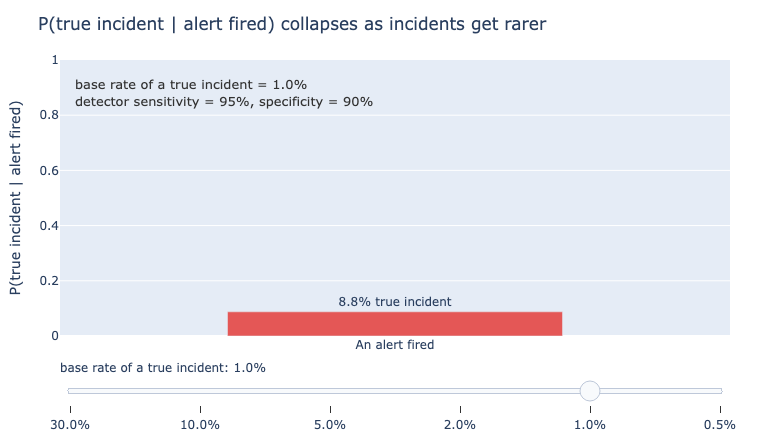

In [5]:
show(fig_bayes_base_rate())

## Matching a distribution to the mechanism

The shaded band marks one standard deviation on either side of the mean, and roughly 68% of the curve's area falls inside it. Dragging the standard-deviation slider stretches or compresses the whole curve, but the same 68-95-99.7 split of the area holds at every scale.

In [6]:
def fig_normal_empirical_rule() -> go.Figure:
    stds = [1, 2, 3, 5, 8]
    x = np.linspace(-30, 30, 600)
    frames = []
    for sd in stds:
        pdf = stats.norm.pdf(x, loc=0, scale=sd)
        frames.append(
            go.Frame(
                name=str(sd),
                data=[go.Scatter(x=x, y=pdf, mode="lines", fill="tozeroy",
                                  line=dict(color="#4C78A8", width=2))],
                layout=go.Layout(shapes=[
                    dict(type="line", x0=-sd, x1=-sd, y0=0, y1=1, yref="paper",
                         line=dict(color="#54A24B", width=1.5, dash="dot")),
                    dict(type="line", x0=sd, x1=sd, y0=0, y1=1, yref="paper",
                         line=dict(color="#54A24B", width=1.5, dash="dot")),
                ]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="The normal distribution reshapes with the standard deviation; "
              "68% of mass always sits within one std. of the mean",
        xaxis_title="value (centered on the mean)",
        yaxis_title="density",
        xaxis_range=[-30, 30],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "standard deviation: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=70, l=60, r=30, b=50),
    )
    return fig

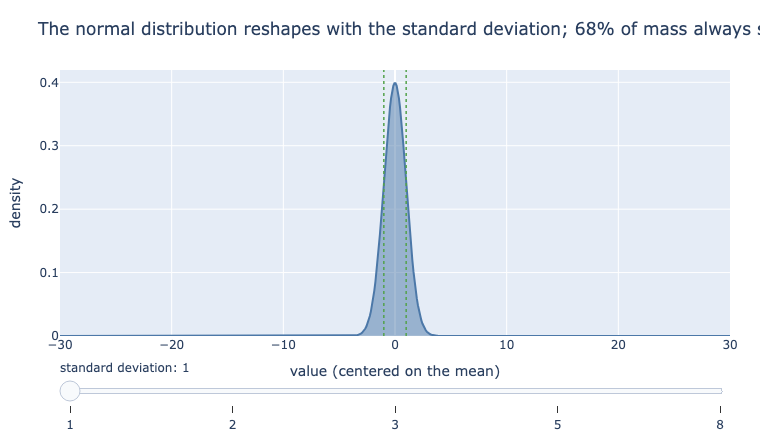

In [7]:
show(fig_normal_empirical_rule())

## Matching a distribution to the mechanism

The tail probability P(Z > z) beyond a given z-score. Moving the threshold from 0.5 to 3.0 standard deviations shrinks the tail from roughly 31% of the distribution to about 0.1%.

In [8]:
def fig_standard_normal_zscore() -> go.Figure:
    z_thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
    x = np.linspace(-4, 4, 400)
    pdf_full = stats.norm.pdf(x)
    frames = []
    for z in z_thresholds:
        tail_x = np.linspace(z, 4, 100)
        tail_y = stats.norm.pdf(tail_x)
        tail_prob = 1 - stats.norm.cdf(z)
        frames.append(
            go.Frame(
                name=f"{z:.1f}",
                data=[
                    go.Scatter(x=x, y=pdf_full, mode="lines",
                               line=dict(color="#4C78A8", width=2)),
                    go.Scatter(x=tail_x, y=tail_y, mode="lines", fill="tozeroy",
                               line=dict(color="#E45756", width=0),
                               fillcolor="rgba(228,87,86,0.55)"),
                ],
                layout=go.Layout(
                    shapes=[dict(type="line", x0=z, x1=z, y0=0, y1=1, yref="paper",
                                 line=dict(color="#E45756", width=1.5, dash="dot"))],
                    annotations=[dict(
                        x=0.02, y=0.92, xref="paper", yref="paper", showarrow=False,
                        align="left",
                        text=f"z = {z:.1f}<br>P(Z > z) = {tail_prob:.1%}",
                        font=dict(size=13, color="#333"),
                    )],
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="How fast the tail probability shrinks as a z-score climbs",
        xaxis_title="z (standard deviations from the mean)",
        yaxis_title="density",
        xaxis_range=[-4, 4],
        showlegend=False,
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "z-score threshold: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

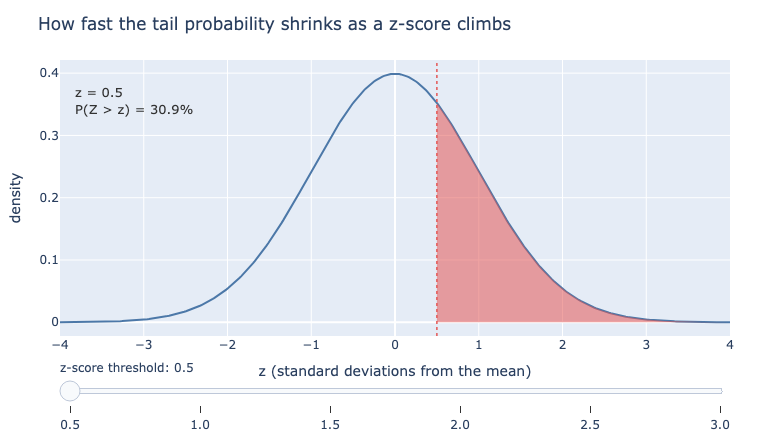

In [9]:
show(fig_standard_normal_zscore())

## Matching a distribution to the mechanism

A uniform draw on [0, 1] split by a rollout threshold. Moving the threshold from 0.05 to 1.00 grows the treatment share from 5% of users to all of them, matching the threshold value.

In [10]:
def fig_uniform_rollout() -> go.Figure:
    thresholds = [0.05, 0.10, 0.25, 0.50, 0.75, 1.00]
    x = np.linspace(0, 1, 200)
    frames = []
    for t in thresholds:
        treat_mask = x <= t
        control_mask = ~treat_mask
        frames.append(
            go.Frame(
                name=f"{t:.2f}",
                data=[
                    go.Scatter(x=x[treat_mask], y=np.ones(int(treat_mask.sum())),
                               mode="lines", fill="tozeroy",
                               line=dict(color="#54A24B", width=0),
                               fillcolor="rgba(84,162,75,0.6)"),
                    go.Scatter(x=x[control_mask], y=np.ones(int(control_mask.sum())),
                               mode="lines", fill="tozeroy",
                               line=dict(color="#B0B0B0", width=0),
                               fillcolor="rgba(176,176,176,0.45)"),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.92, xref="paper", yref="paper", showarrow=False,
                    align="left",
                    text=f"threshold = {t:.2f}<br>{t:.0%} of users enrolled in treatment",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A feature-flag rollout threshold splits a uniform draw into treatment and control",
        xaxis_title="uniformly random draw per user, between 0 and 1",
        yaxis_title="density",
        xaxis_range=[0, 1],
        yaxis_range=[0, 1.2],
        showlegend=False,
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "rollout threshold: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

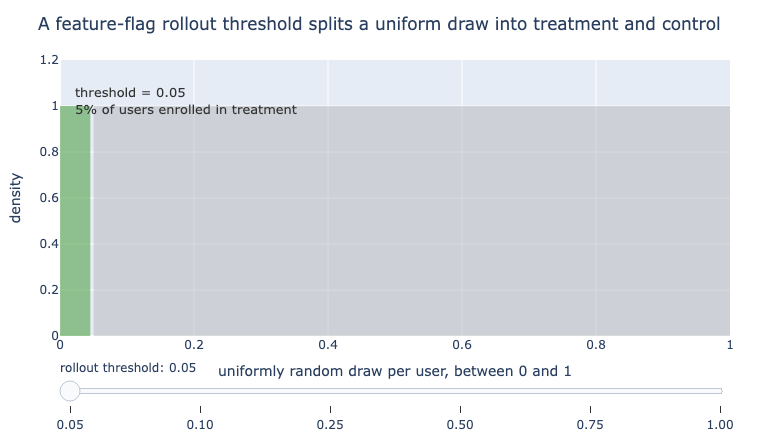

In [11]:
show(fig_uniform_rollout())

## Matching a distribution to the mechanism

A single Bernoulli trial's two possible outcomes, at success probabilities from 10% to 90%. The two bars always sum to 100%, since a Bernoulli trial has no third outcome.

In [12]:
def fig_bernoulli_trial() -> go.Figure:
    probs = [0.1, 0.3, 0.5, 0.7, 0.9]
    frames = []
    for p in probs:
        frames.append(
            go.Frame(
                name=f"{p:.1f}",
                data=[go.Bar(
                    x=["failure (0)", "success (1)"], y=[1 - p, p],
                    marker_color=["#B0B0B0", "#4C78A8"],
                    text=[f"{1 - p:.0%}", f"{p:.0%}"], textposition="outside",
                )],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="A single Bernoulli trial: probability of success versus failure",
        yaxis_title="probability",
        yaxis_range=[0, 1.15],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "probability of success (p): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

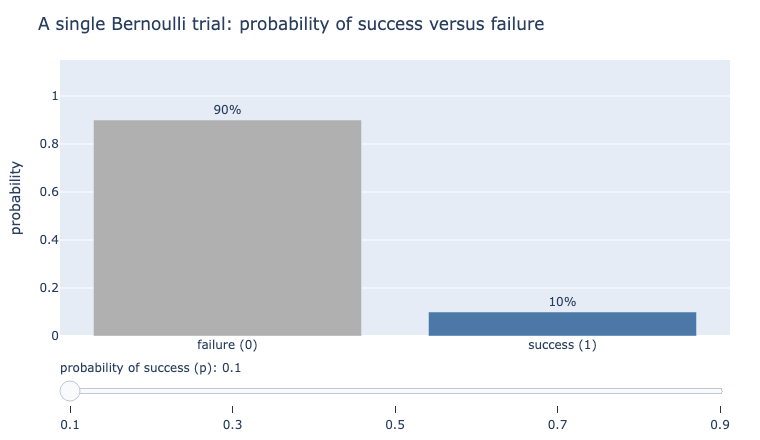

In [13]:
show(fig_bernoulli_trial())

## Matching a distribution to the mechanism

Number of conversions out of a fixed 50-visitor bucket, by the true underlying conversion probability. Both the center and the spread of the distribution shift as that probability rises.

In [14]:
def fig_binomial_conversions() -> go.Figure:
    n_trials = 50
    conv_probs = [0.05, 0.10, 0.20, 0.35, 0.50]
    x = np.arange(0, n_trials + 1)
    frames = []
    for p in conv_probs:
        pmf = stats.binom.pmf(x, n_trials, p)
        expected = n_trials * p
        frames.append(
            go.Frame(
                name=f"{p:.2f}",
                data=[go.Bar(x=x, y=pmf, marker_color="#B279A2")],
                layout=go.Layout(
                    xaxis=dict(range=[-0.5, min(n_trials, expected + 4 * (n_trials * p * (1 - p)) ** 0.5 + 5)]),
                    annotations=[dict(
                        x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                        xanchor="right",
                        text=f"expected conversions = {expected:.1f} of {n_trials}",
                        font=dict(size=13, color="#333"),
                    )],
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title=f"Conversions out of a {n_trials}-visitor A/B bucket, by true conversion rate",
        xaxis_title="number of conversions",
        yaxis_title="probability",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "true conversion probability: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

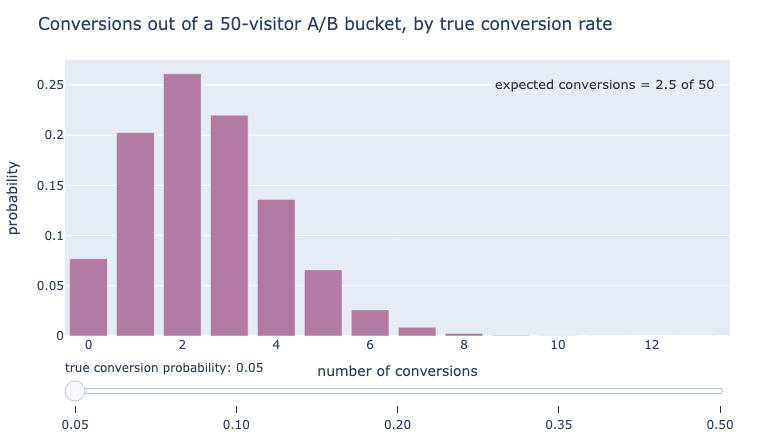

In [15]:
show(fig_binomial_conversions())

## Matching a distribution to the mechanism

The distribution of attempts needed before a flaky call succeeds, and how its expected value rises sharply as reliability drops.

In [16]:
def fig_geometric_retries() -> go.Figure:
    success_probs = [0.9, 0.7, 0.5, 0.3, 0.15]
    x = np.arange(1, 16)
    frames = []
    for p in success_probs:
        pmf = stats.geom.pmf(x, p)
        expected = 1 / p
        frames.append(
            go.Frame(
                name=f"{p:.2f}",
                data=[go.Bar(x=x, y=pmf, marker_color="#F58518")],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=f"expected retries to first success = {expected:.1f}",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Retries needed before a flaky call finally succeeds",
        xaxis_title="attempt number of the first success",
        yaxis_title="probability",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "per-attempt success probability: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

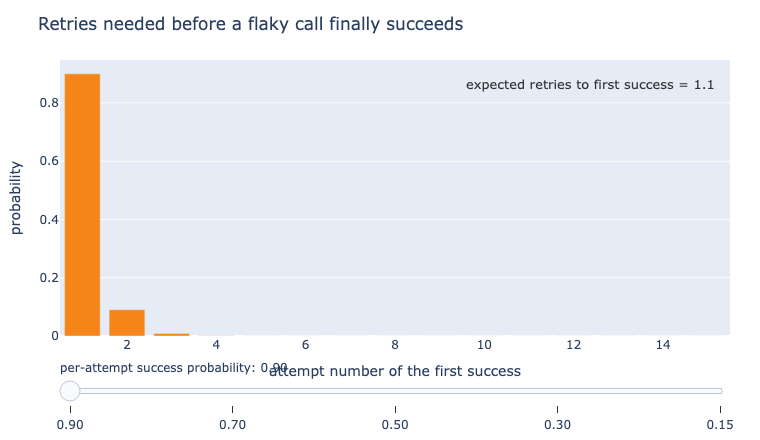

In [17]:
show(fig_geometric_retries())

## Matching a distribution to the mechanism

The Poisson distribution's shape at low request rates versus high ones. At high enough $\lambda$, the shape looks close to normal, another instance of the Central Limit Theorem's reach.

In [18]:
def fig_poisson_shape() -> go.Figure:
    lambdas = [1, 3, 8, 15, 30, 60]
    frames = []
    for lam in lambdas:
        x = np.arange(0, max(20, lam * 3))
        pmf = stats.poisson.pmf(x, lam)
        frames.append(
            go.Frame(
                name=str(lam),
                data=[go.Bar(x=x, y=pmf, marker_color="#72B7B2")],
                layout=go.Layout(xaxis=dict(range=[0, max(20, lam * 2)])),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Poisson request-arrival counts look more like a normal curve as the rate grows",
        xaxis_title="requests in one second",
        yaxis_title="probability",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "mean requests per second (lambda): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

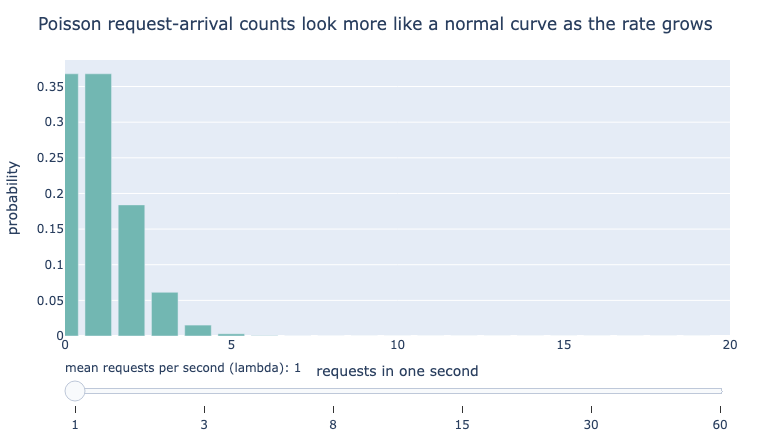

In [19]:
show(fig_poisson_shape())

## Matching a distribution to the mechanism

Wait-time density at rates from 0.25 to 4 events per unit time. A higher rate pulls the whole curve toward zero: the mean wait is always $1/\lambda$, so the probability of a short wait climbs fast as the rate increases.

In [20]:
def fig_exponential_wait() -> go.Figure:
    lambdas = [0.25, 0.5, 1.0, 2.0, 4.0]
    x = np.linspace(0, 8, 400)
    frames = []
    for lam in lambdas:
        pdf = stats.expon.pdf(x, scale=1 / lam)
        mean_wait = 1 / lam
        p_within_1 = stats.expon.cdf(1, scale=1 / lam)
        frames.append(
            go.Frame(
                name=f"{lam:.2f}",
                data=[go.Scatter(x=x, y=pdf, mode="lines", fill="tozeroy",
                                  line=dict(color="#72B7B2", width=2))],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.92, xref="paper", yref="paper", showarrow=False,
                    xanchor="right", align="right",
                    text=(f"mean wait = {mean_wait:.2f}<br>"
                          f"P(wait under 1 unit) = {p_within_1:.0%}"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Wait time until the next event, at different constant rates",
        xaxis_title="time until the next event",
        yaxis_title="density",
        xaxis_range=[0, 8],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "rate (lambda, events per unit time): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

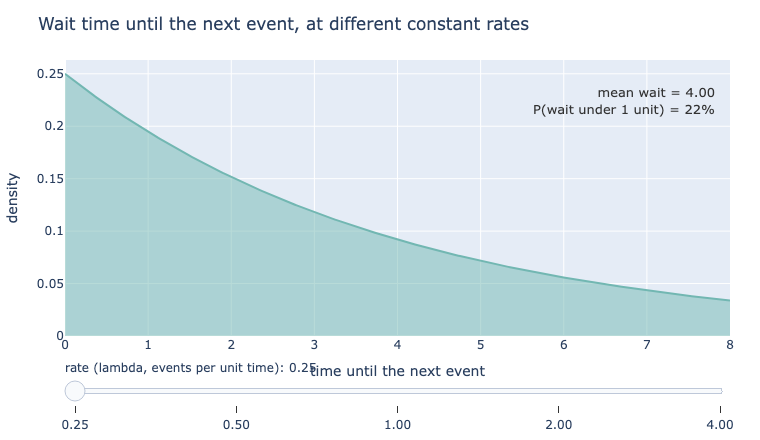

In [21]:
show(fig_exponential_wait())

## The Central Limit Theorem

Sample means of a skewed parent distribution become normal-shaped as sample size grows, the same property that makes the t-test in Chapter 2 usable even on non-normal data at moderate sample sizes.

In [22]:
def fig_clt_simulation() -> go.Figure:
    sample_sizes = [1, 2, 5, 10, 30, 100]
    n_draws = 4000
    frames = []
    for n in sample_sizes:
        parent = RNG.exponential(scale=1.0, size=(n_draws, n))
        sample_means = parent.mean(axis=1)
        hist = np.histogram(sample_means, bins=60, range=(0, 4))
        frames.append(
            go.Frame(
                name=str(n),
                data=[go.Bar(x=hist[1][:-1], y=hist[0], marker_color="#B279A2")],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Sample means of a skewed (exponential) parent distribution turn normal-shaped "
              "as sample size grows",
        xaxis_title="sample mean",
        yaxis_title="count across 4,000 simulated samples",
        xaxis_range=[0, 4],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "observations per sample (n): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

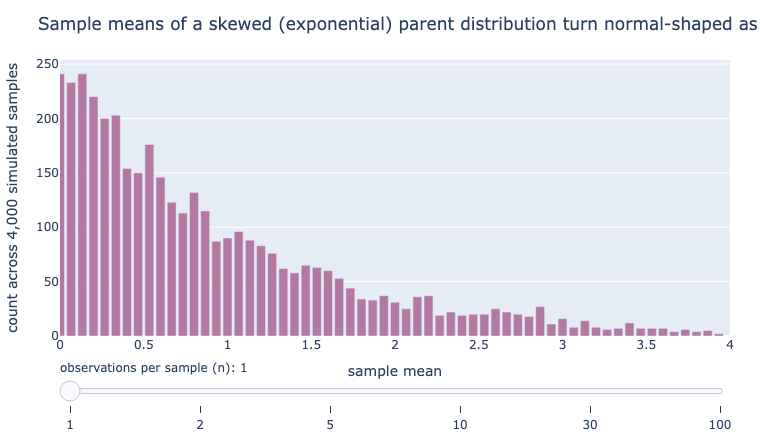

In [23]:
show(fig_clt_simulation())

## The birthday problem: collisions in a space that felt safe

Collision probability for randomly generated identifiers, by identifier length in bits. The x-axis is on a log scale: an 8-bit ID space collides almost immediately, while a 64-bit space needs billions of IDs before collisions become likely.

In [24]:
def fig_birthday_collision() -> go.Figure:
    id_bits_options = [8, 16, 24, 32, 48, 64]
    frames = []
    for bits in id_bits_options:
        space = 2 ** bits
        n = np.unique(np.round(np.geomspace(2, min(space, 2 ** 26), 200)).astype(np.int64))
        # Standard birthday-problem approximation: P(collision) ~ 1 - exp(-n^2 / (2 * space))
        p_collision = 1 - np.exp(-(n.astype(np.float64) ** 2) / (2 * space))
        frames.append(
            go.Frame(
                name=str(bits),
                data=[go.Scatter(x=n, y=p_collision, mode="lines",
                                  line=dict(color="#4C78A8", width=3))],
                layout=go.Layout(xaxis=dict(type="log", range=[np.log10(2), np.log10(n.max())])),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="How many randomly generated IDs before two collide, by ID length",
        xaxis_title="IDs generated so far (log scale)",
        yaxis_title="probability at least two collide",
        yaxis_range=[0, 1],
        shapes=[dict(type="line", x0=0, x1=1, xref="paper", y0=0.5, y1=0.5,
                     line=dict(color="#E45756", width=1.5, dash="dash"))],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "ID length (bits): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

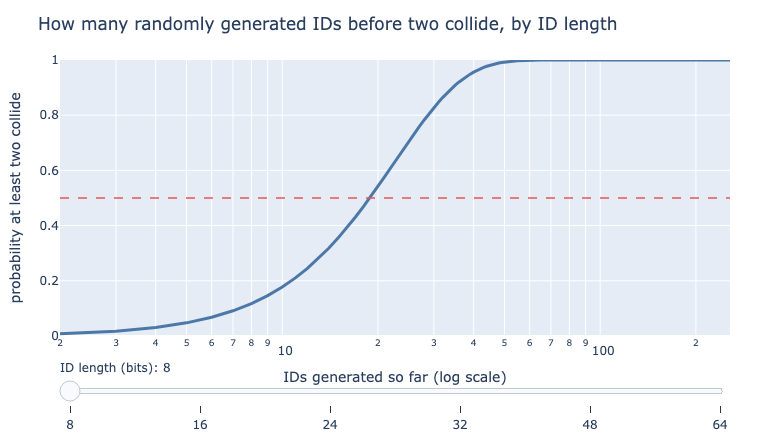

In [25]:
show(fig_birthday_collision())